In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from typing import Dict, List, Tuple, Optional
import logging
from pathlib import Path
from tqdm import tqdm
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix
)
import cv2
import seaborn as sns
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import wandb
import random
%matplotlib inline

In [ ]:
class LungCancerDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.transform = transform
        self.classes = ['Benign cases', 'Malignant cases', 'Normal cases']
        self.images = []
        self.labels = []

        # Set path to either train_images or test_images
        data_dir = os.path.join(root_dir, f"{split}_images")

        # Load image paths and labels
        for images_path in os.listdir(data_dir):
            for idx,cls in enumerate(self.classes):
                
                if images_path.find(cls)==-1:
                
                    class_dir = os.path.join(data_dir, images_path)
                 
                    self.images.append(class_dir)
                    self.labels.append(idx)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [54]:
config = {
    'data_dir': '/kaggle/input/iq-othncc-lung-cancertrain-and-test-split',  
    'batch_size': 32,
    'learning_rate': 0.00001,
    'epochs': 50,
    'num_heads': 4,
    'key_dim': 16,
    'dropout': 0.5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
    }

In [47]:
len(images)

877

In [1]:
import os
import shutil
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import re

def split_lung_dataset(dataset_path, output_path='lung_split', test_size=0.2, random_state=42):
    """
    Split lung cancer dataset using sklearn train_test_split
    """
    
    # Create output directories
    train_dir = Path(output_path) / 'train'
    test_dir = Path(output_path) / 'test'
    
    # Class folders
    classes = {
        'Bengin cases': 'bengin',
        'Malignant cases': 'malignant', 
        'Normal cases': 'normal'
    }
    
    for class_name in classes.values():
        (train_dir / class_name).mkdir(parents=True, exist_ok=True)
        (test_dir / class_name).mkdir(parents=True, exist_ok=True)
    
    print(f"Created directories in: {output_path}")
    
    # Collect all patient data
    all_patients = []
    
    for class_folder, class_name in classes.items():
        folder_path = Path(dataset_path) / class_folder
        
        if not folder_path.exists():
            print(f"Folder not found: {folder_path}")
            continue
        
        # Get all images
        images = list(folder_path.glob('*.jpg')) + list(folder_path.glob('*.jpeg')) + list(folder_path.glob('*.png'))
        
        if not images:
            print(f"No images in {class_folder}")
            continue
        
        print(f"Found {len(images)} images in {class_folder}")
        
        # Group by patient ID
        patient_groups = {}
        for img in images:
            # Extract patient ID from filename like "Bengin case (1).jpg"
            match = re.search(r'\((\d+)\)', img.name)
            patient_id = match.group(1) if match else img.stem
            
            if patient_id not in patient_groups:
                patient_groups[patient_id] = []
            patient_groups[patient_id].append(img)
        
        # Add to all patients list
        for pid, imgs in patient_groups.items():
            all_patients.append({
                'patient_id': f"{class_name}_{pid}",
                'class': class_name,
                'images': imgs,
                'count': len(imgs)
            })
        
        print(f"Patients in {class_folder}: {len(patient_groups)}")
    
    # Convert to arrays for sklearn
    X = [[p['patient_id'], p['images']] for p in all_patients]
    y = [p['class'] for p in all_patients]
    
    print(f"\nTotal patients: {len(all_patients)}")
    print(f"Total images: {sum(p['count'] for p in all_patients)}")
    
    # Split using sklearn
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state,
        stratify=y
    )
    
    print(f"\nTrain patients: {len(X_train)}")
    print(f"Test patients: {len(X_test)}")
    
    # Copy files
    train_count = 0
    test_count = 0
    
    # Copy train files
    for (patient_id, images), class_label in zip(X_train, y_train):
        for img in images:
            dest = train_dir / class_label / img.name
            shutil.copy2(img, dest)
            train_count += 1
    
    # Copy test files
    for (patient_id, images), class_label in zip(X_test, y_test):
        for img in images:
            dest = test_dir / class_label / img.name
            shutil.copy2(img, dest)
            test_count += 1
    
    print(f"\nTrain images: {train_count}")
    print(f"Test images: {test_count}")
    print(f"Total copied: {train_count + test_count}")
    
    # Save split info
    split_info = []
    for (patient_id, images), class_label in zip(X_train + X_test, y_train + y_test):
        split_type = 'train' if (patient_id, images) in [(x[0], x[1]) for x in X_train] else 'test'
        split_info.append({
            'patient_id': patient_id,
            'class': class_label,
            'split': split_type,
            'num_images': len(images)
        })
    
    df = pd.DataFrame(split_info)
    df.to_csv(Path(output_path) / 'split_info.csv', index=False)
    
    print(f"\nSplit info saved to: {Path(output_path) / 'split_info.csv'}")
    print(f"Output folder: {output_path}")
    
    return {
        'train_images': train_count,
        'test_images': test_count,
        'train_patients': len(X_train),
        'test_patients': len(X_test)
    }

# Usage
dataset_path = "/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset"  # UPDATE THIS PATH
results = split_lung_dataset(dataset_path)


Created directories in: lung_split
Found 120 images in Bengin cases
Patients in Bengin cases: 120
Found 561 images in Malignant cases
Patients in Malignant cases: 561
Found 416 images in Normal cases
Patients in Normal cases: 416

Total patients: 1097
Total images: 1097

Train patients: 877
Test patients: 220

Train images: 877
Test images: 220
Total copied: 1097

Split info saved to: lung_split/split_info.csv
Output folder: lung_split


In [2]:
import os
import zipfile

root_dir = "/kaggle/working/lung_split"
zip_path = "/kaggle/working/lung_split.zip"

with zipfile.ZipFile(zip_path, mode='w', compression=zipfile.ZIP_STORED) as zf:
    for folder, _, files in os.walk(root_dir):
        for file in files:
            file_path = os.path.join(folder, file)
            # Store relative paths inside the zip
            arcname = os.path.relpath(file_path, root_dir)
            zf.write(file_path, arcname=arcname)

print(f"Created lossless ZIP at: {zip_path}")


Created lossless ZIP at: /kaggle/working/lung_split.zip


In [4]:
# classes = ['Benign cases', 'Malignant cases', 'Normal cases']
# folder_name = "train_images"
# os.makedirs(folder_name, exist_ok=True)

# for idx,(img,lbl) in enumerate(train_dataset):
#     lbl_to_class = classes[lbl]
#     # print(idx,img.shape, lbl)
#     filename = f"{lbl_to_class}_{idx}.png"
#     path_main = filename  # Save in working directory
#     path_folder = os.path.join(folder_name, filename)  # Save in subfolder

#     cv2.imwrite(path_folder, img)
#     # cv2.imshow(img,"img")
#     # break

In [5]:
# import zipfile
# zip_filename = "train_images.zip"
# with zipfile.ZipFile(zip_filename, 'w') as zipf:
#     for root, _, files in os.walk(folder_name):
#         for file in files:
#             file_path = os.path.join(root, file)
#             zipf.write(file_path, arcname=os.path.relpath(file_path, folder_name))

In [6]:
class CNN_Model1(nn.Module):
    def __init__(self,inp_chn = 3, out_chn=32):
        super(CNN_Model1,self).__init__()
        self.conv1 = nn.Conv2d(inp_chn,out_chn,kernel_size=3,padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(out_chn,out_chn*2,kernel_size=3,padding=1)
        self.conv3 = nn.Conv2d(out_chn*2,out_chn*2,kernel_size=3,padding=1)

        self.conv4 = nn.Conv2d(out_chn*2,out_chn*4,kernel_size=3,padding=1)
        self.conv5= nn.Conv2d(out_chn*4,out_chn*4,kernel_size=3,padding=1)
        
        self.conv6 = nn.Conv2d(out_chn*4,out_chn*8,kernel_size=3,padding=1)
        self.global_max_pool = nn.AdaptiveMaxPool2d(1)

    def forward(self,x):
        # print(x.shape)
        x = self.relu(self.conv1(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = self.relu(self.conv2(x))
        # print(x.shape)
        x = self.relu(self.conv3(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = self.relu(self.conv4(x))
        # print(x.shape)
        x = self.relu(self.conv5(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = self.relu(self.conv6(x))
        # print(x.shape)
        x = self.global_max_pool(x)
        # print(x.shape)

        # print(x.view(x.shape[0],-1).shape)
        return x.view(x.shape[0],-1)  # return (B,C) = (1,256)

class CNN_Model2(nn.Module):
    def __init__(self,inp_chn = 3, out_chn=16):
        super(CNN_Model2,self).__init__()
        self.conv1 = nn.Conv2d(inp_chn,out_chn,kernel_size=3,padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(out_chn,out_chn*2,kernel_size=3,padding=1)
        self.global_max_pool = nn.AdaptiveMaxPool2d(1)

    def forward(self,x):
        # print(x.shape)
        x = self.relu(self.conv1(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = self.relu(self.conv2(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = self.global_max_pool(x)
        # print(x.shape)
        # print(x.view(x.shape[0],-1).shape)
        return x.view(x.shape[0],-1) # return (B,C) = (1,32)
        
class MainModel(nn.Module):
    def __init__(self, num_classes=3, num_heads=4, key_dim=16, num_tokens=4, dropout_p=config['dropout']):
        super(MainModel, self).__init__()
        self.cnn1 = CNN_Model1()              # (B, C)
        self.cnn2 = CNN_Model2()              # ( B, C)
        concat_dim = 256 + 32                 # 288 per paper

        # Attention width per PyTorch: embed_dim = num_heads * key_dim = 64
        embed_dim = num_heads * key_dim       # mirrors heads=4, key_dim=16 in paper
        self.embed_dim = embed_dim
        self.num_heads = num_heads

        # Project 288 → (T * E), then reshape to (B, T, E) for MHA
        self.feature_projection = nn.Linear(concat_dim, self.num_heads  * embed_dim)

        # Two stacked MHA layers 
        self.mha1 = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, dropout=0.1, batch_first=True)
        self.mha2 = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, dropout=0.1, batch_first=True)

        # MLP head mirrors: GAP1D → BN → Dense(256) → GELU → BN → Dropout → Dense(3)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.batch_norm1 = nn.BatchNorm1d(embed_dim)
        self.dense1 = nn.Linear(embed_dim, 256)
        self.gelu = nn.GELU()
        self.batch_norm2 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(dropout_p)
        self.ffn = nn.Linear(256, num_classes)

    def forward(self, x):
        f1 = self.cnn1(x)                                    # B × 256
        f2 = self.cnn2(x)                                    # B × 32
        concat_features = torch.cat([f1, f2], dim=1)         # B × 288

        proj = self.feature_projection(concat_features)      # B × (T*E)
        tokens = proj.view(proj.size(0), self.num_heads , self.embed_dim)  # B × T × E

        attn_out1, attn_w1 = self.mha1(tokens, tokens, tokens)             # B × T × E
        attn_out2, attn_w2 = self.mha2(attn_out1, attn_out1, attn_out1)    # B × T × E

        x = attn_out2.transpose(1, 2)                        # B × E × T
        x = self.global_avg_pool(x).squeeze(-1)              # B × E

        x = self.batch_norm1(x)
        x = self.dense1(x)
        x = self.gelu(x)
        x = self.batch_norm2(x)
        x = self.dropout(x)
        logits = self.ffn(x)
        # Optionally return both attention maps
        return logits, (attn_w1, attn_w2)


In [7]:
def load_best_model(model, device='cuda'):
    """Load the saved best model"""
    checkpoint = torch.load('/kaggle/input/base_model/pytorch/default/1/best_model.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f'Loaded best model from epoch {checkpoint["epoch"]}')
    print(f'Best validation accuracy: {checkpoint["val_acc"]:.2f}%')
    
    return model

In [37]:
test_transforms = transforms.Compose([
    # CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8)),   # CLAHE
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [58]:
test_dataset = LungCancerDataset(config['data_dir'], 'test',test_transforms)

In [59]:
len(test_dataset)

220

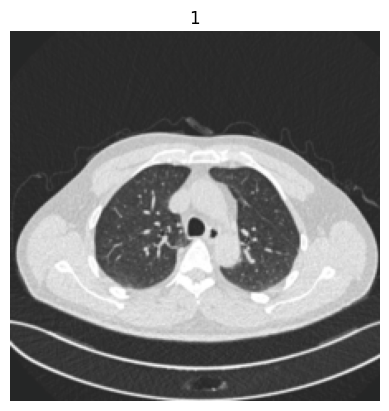

In [10]:
def unnormalize_and_show(tensor,lbl, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], show=True):
    """
    Unnormalizes a tensor image and optionally displays it using matplotlib.

    Args:
        tensor (torch.Tensor): Normalized image tensor of shape [3, H, W].
        mean (list): Mean used for normalization.
        std (list): Std used for normalization.
        show (bool): If True, displays the image using matplotlib.

    Returns:
        torch.Tensor: Unnormalized image tensor.
    """
    if tensor.ndim != 3 or tensor.shape[0] != 3:
        raise ValueError("Input tensor must have shape [3, H, W]")

    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    unnorm = tensor * std + mean
    unnorm = unnorm.clamp(0, 1)  # Ensure values are in [0, 1] for display

    if show:
        img_np = unnorm.permute(1, 2, 0).cpu().numpy()
        plt.imshow(img_np)
        plt.axis('off')
        plt.title(lbl)
        plt.show()

    return unnorm
for img ,lbl in test_dataset:
    
    unnormalize_and_show(img,lbl)
    break

In [ ]:
len(test_dataset)

In [12]:

model = MainModel(
    num_classes=3,
    num_heads=config['num_heads'],
    key_dim=config['key_dim'],
    dropout_p = config['dropout']
)

model = load_best_model(model,'cpu')

Loaded best model from epoch 44
Best validation accuracy: 99.55%


In [13]:


# Create data loaders
# train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)


In [ ]:
len(test_loader)

In [ ]:
for idx,(img,lbl) in enumerate(test_loader):
    print(img.shape,lbl)
    break

In [ ]:
# device = 'cpu'
# model.eval()
# with torch.no_grad():
#     for idx, (img,lbl) in enumerate(test_loader):
#         # print(img.shape)
#         img, lbl = img.to(device), lbl.to(device)
#         outputs, _ = model(img)
#         probs = F.softmax(outputs, dim=1)
        
#         _, predicted = outputs.max(1)
#         # all_preds.extend(predicted.cpu().numpy())
#         # all_targets.extend(targets.cpu().numpy())
#         # all_probs.extend(probs.cpu().numpy())
#         print(lbl,predicted)
        
        

In [62]:


def evaluate_model(model, test_loader, device='cuda'):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for data, targets in tqdm(test_loader, desc='Testing'):
            data, targets = data.to(device), targets.to(device)
            outputs, _ = model(data)
            probs = F.softmax(outputs, dim=1)
            
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='weighted')
    recall = recall_score(all_targets, all_preds, average='weighted')
    f1 = f1_score(all_targets, all_preds, average='weighted')
    auc = roc_auc_score(all_targets, np.array(all_probs), multi_class='ovr', average='weighted')

    # Simple results display
    print(f'\nTest Results:')
    print(f'Accuracy:  {accuracy*100:.2f}%')
    print(f'Precision: {precision*100:.2f}%')
    print(f'Recall:    {recall*100:.2f}%')
    print(f'F1-Score:  {f1*100:.2f}%')
    print(f'AUC:       {auc*100:.2f}%')

    # # Log to wandb
    # wandb.log({
    #     "test_accuracy": accuracy * 100,
    #     "test_precision": precision * 100,
    #     "test_recall": recall * 100,
    #     "test_f1": f1 * 100,
    #     "test_auc": auc * 100
    # })

    # Simple confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    # wandb.log({"confusion_matrix": wandb.Image(plt)})
    plt.show()

    return accuracy, precision, recall, f1, auc

Testing: 100%|██████████| 440/440 [00:30<00:00, 14.40it/s]



Test Results:
Accuracy:  0.23%
Precision: 0.20%
Recall:    0.23%
F1-Score:  0.21%
AUC:       28.69%


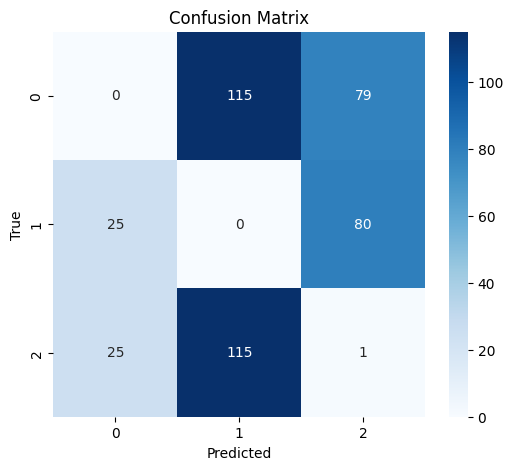

In [63]:
accuracy, precision, recall, f1, auc = evaluate_model(model, test_loader, device='cpu')